In [12]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import resample
from agents.ffnn_agent2 import FFNNAgent
from torch.utils.data import TensorDataset, DataLoader
import torch
import matplotlib.pyplot as plt
import random

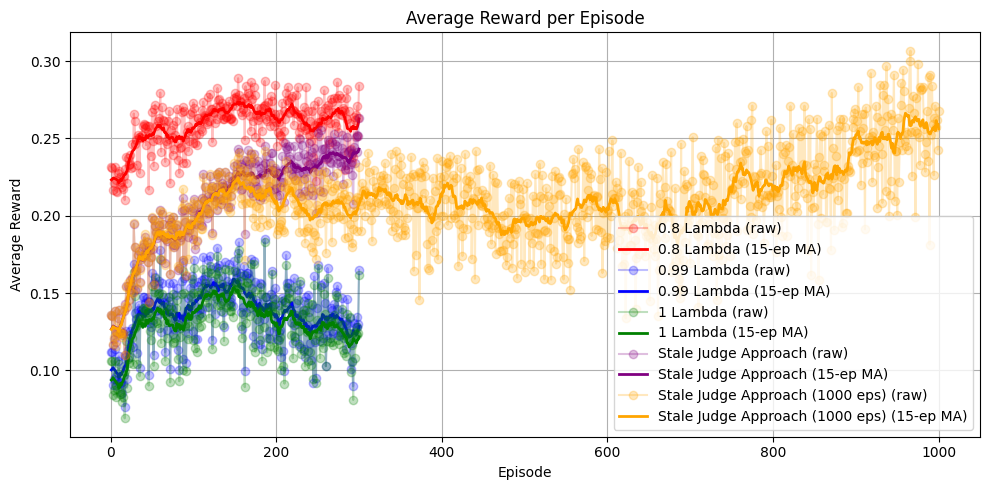

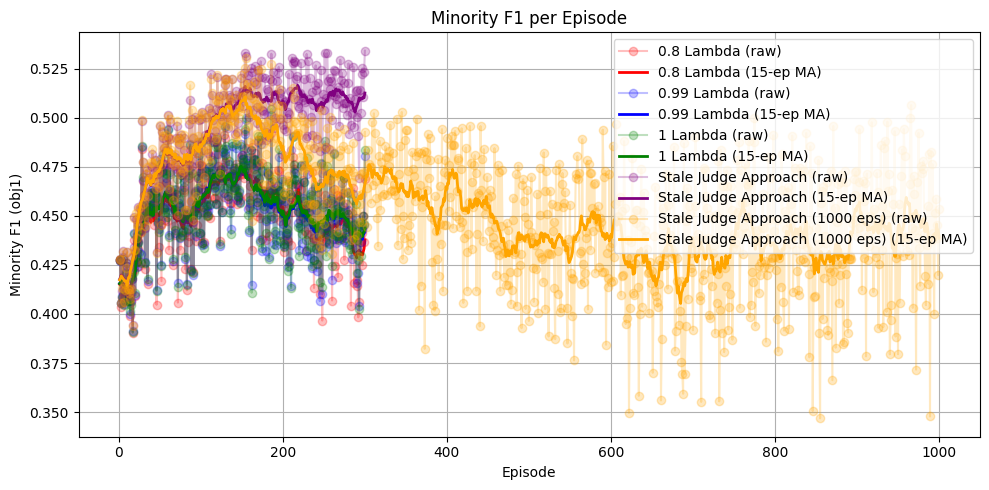

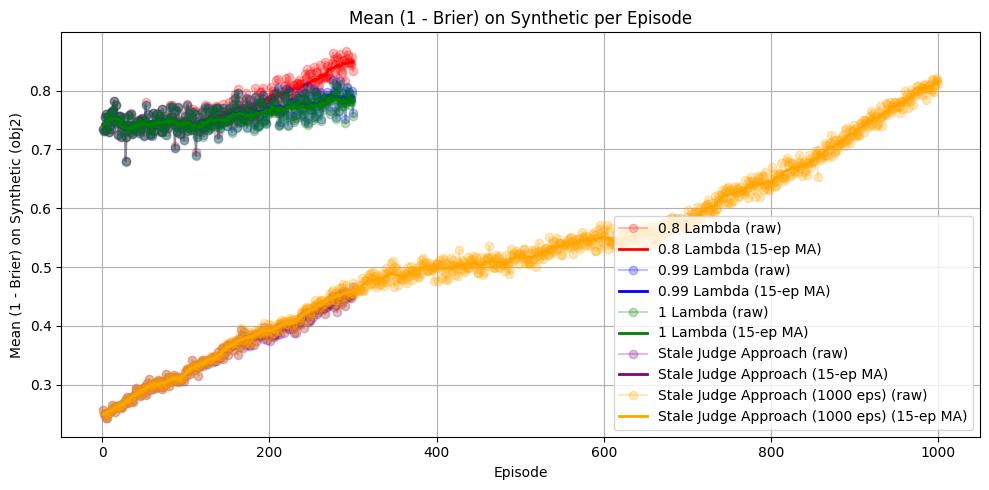

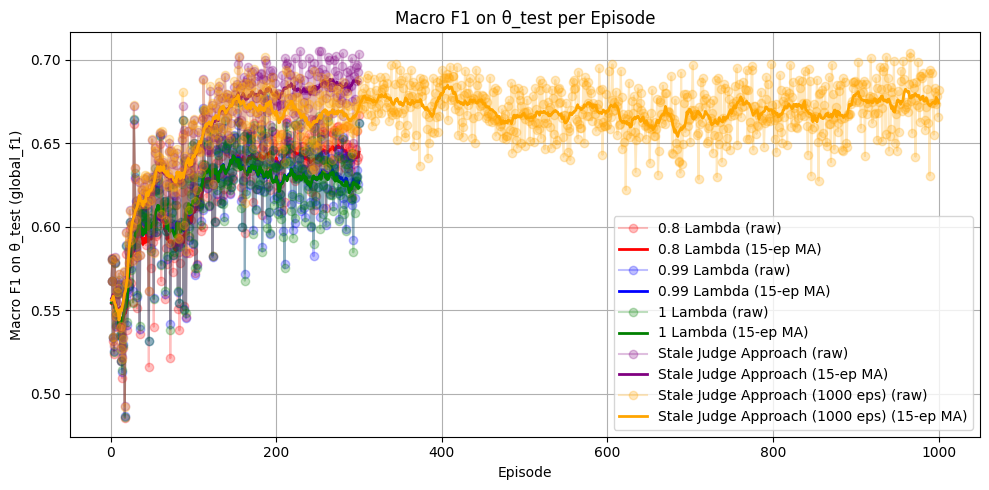

In [18]:
# --- Compare multiple runs on the same plot per metric ---

# The error is caused by a malformed tuple in the 'runs' list.
# Each entry in 'runs' should be a 3-tuple: (path, label, color).
# The last entry is missing a comma between the label and color, so Python concatenates the two strings,
# resulting in a 2-tuple instead of a 3-tuple. This causes unpacking to fail in the for-loop.

# List of runs to compare: (path, label, color)
runs = [
    (
        "training_runs/2025-08-14_17-16-17_EP300_TRJ2000_REAL3000_BIAS0.8_L0.8/",
        "0.8 Lambda",
        "red"
    ),
    (
        "training_runs/2025-08-14_17-52-59_EP300_TRJ2000_REAL3000_BIAS0.8_L0.99/",
        "0.99 Lambda",
        "blue"
    ),
    (
        "training_runs/2025-08-14_18-06-05_EP300_TRJ2000_REAL3000_BIAS0.8_L1/",
        "1 Lambda",
        "green"
    ),
    (
        "training_runs/2025-08-20_12-57-57_EP300_TRJ2000_REAL3000_BIAS0.8_L0.8/",
        "Stale Judge Approach",  # This run used alpha the entire time.
        "Purple"
    ),
    (
        "training_runs/2025-08-20_13-11-15_EP1000_TRJ2000_REAL3000_BIAS0.8_L0.8/",
        "Stale Judge Approach (1000 eps)",#This run also uses alpha and shows the individual reward still eventually dominates and causes adverse affects
        "orange"
    )
]

# Metric configs: (column, ylabel, title)
metric_configs = [
    ('average_reward', 'Average Reward', 'Average Reward per Episode'),
    ('obj1_minority_f1', 'Minority F1 (obj1)', 'Minority F1 per Episode'),
    ('obj2_mean', 'Mean (1 - Brier) on Synthetic (obj2)', 'Mean (1 - Brier) on Synthetic per Episode'),
    ('global_f1', 'Macro F1 on θ_test (global_f1)', 'Macro F1 on θ_test per Episode'),
]

window = 15

# Read all runs' metrics into a list of dicts: {label, color, df}
run_metrics = []
for path, label, color in runs:
    try:
        df = pd.read_csv(path + 'metrics.csv')
        # Coerce all metric columns to numeric
        for col in ['average_reward', 'obj1_minority_f1', 'obj2_mean', 'global_f1']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        run_metrics.append({'label': label, 'color': color, 'df': df})
    except Exception as e:
        print(f"Could not load metrics for {label} at {path}: {e}")

# Plot each metric, overlaying all runs
for col, ylabel, title in metric_configs:
    plt.figure(figsize=(10, 5))
    for run in run_metrics:
        df = run['df']
        label = run['label']
        color = run['color']
        # Compute moving average
        moving_avg = df[col].rolling(window=window, min_periods=1, center=True).mean()
        # Plot raw values (faint)
        plt.plot(df['episode'], df[col], marker='o', linestyle='-', alpha=0.25, color=color, label=f"{label} (raw)")
        # Plot moving average (bold)
        plt.plot(df['episode'], moving_avg, color=color, linewidth=2, label=f"{label} ({window}-ep MA)")
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


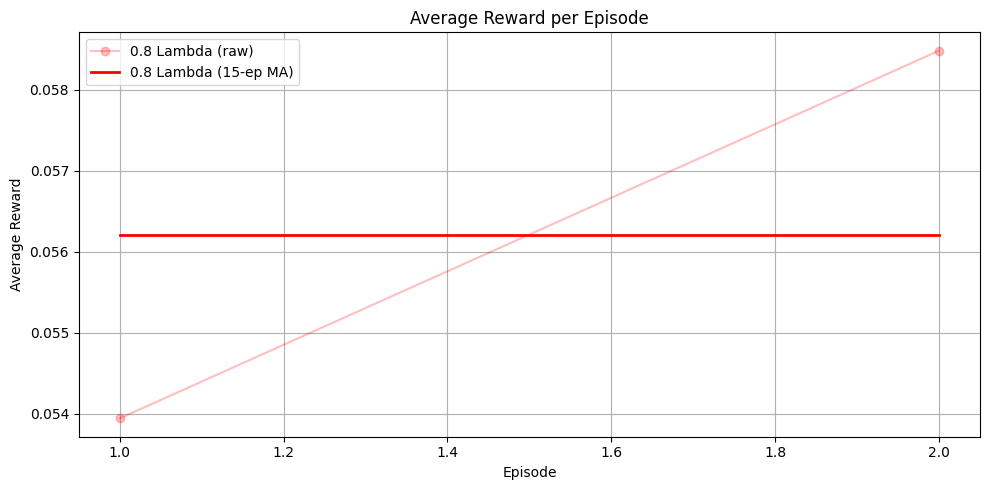

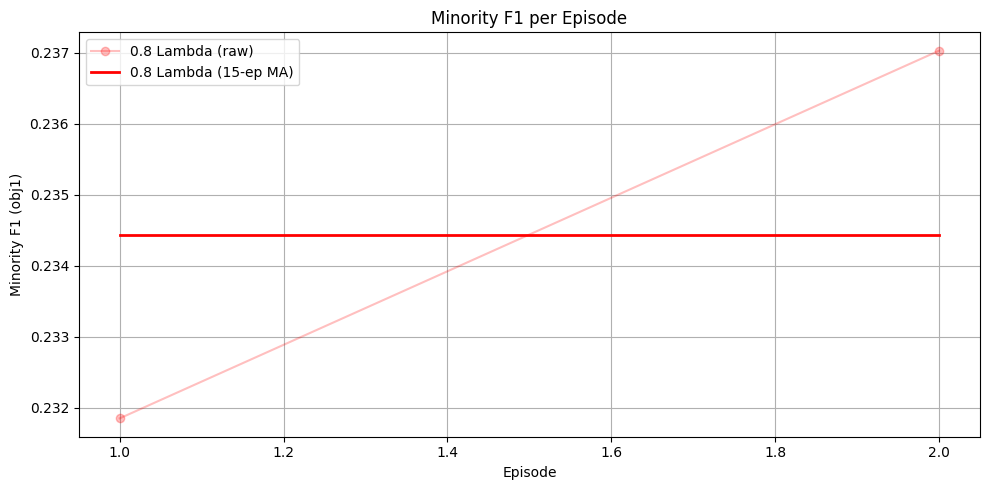

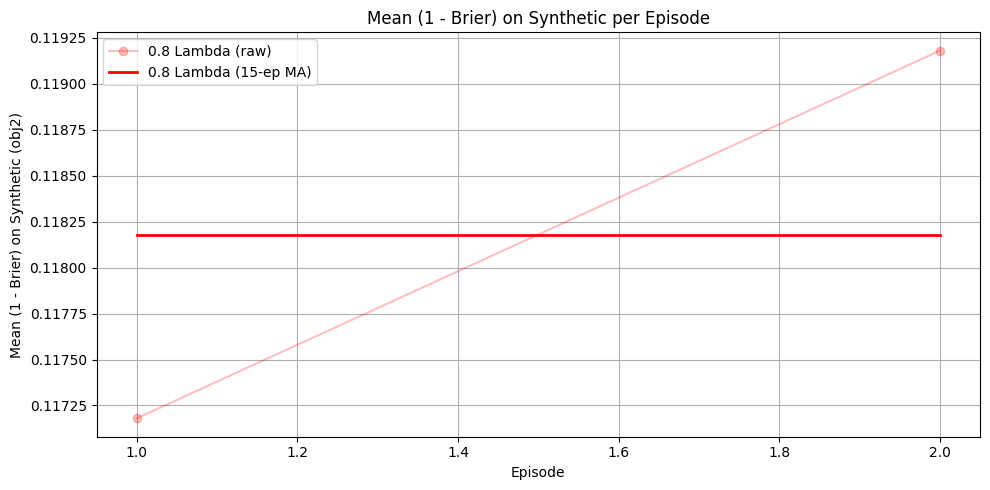

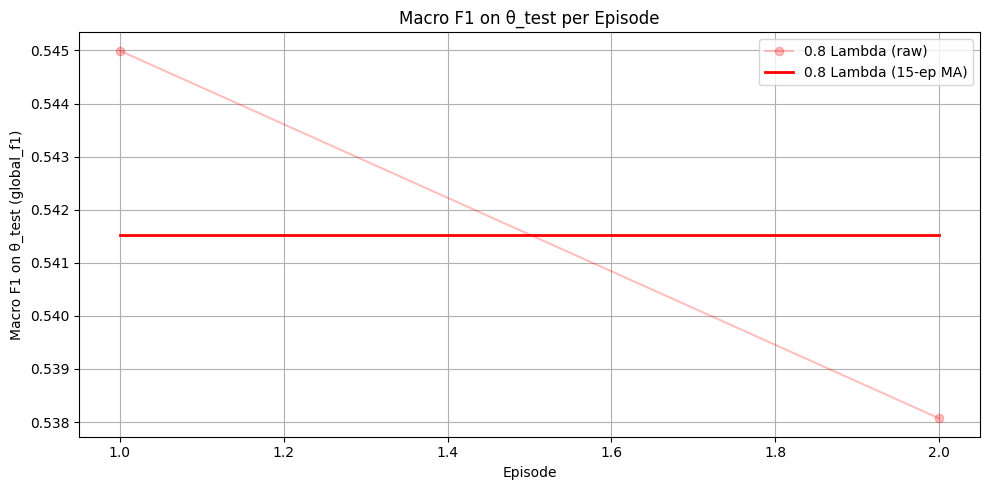

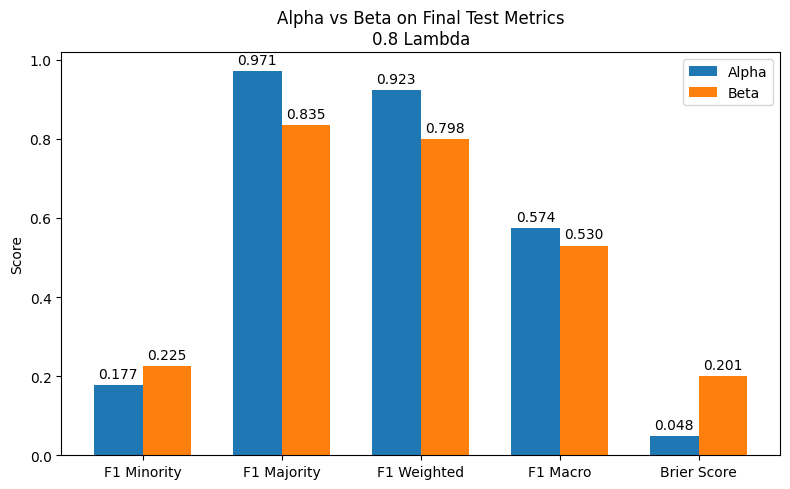

In [20]:
# --- Compare multiple runs on the same plot per metric ---
# In addition, plot bar graphs comparing alpha and beta models on each metric from final_test_metrics.csv per run.

# List of runs to compare: (path, label, color)
runs = [
    (
        "training_runs/2025-08-20_16-21-31_EP2_TRJ2000_REAL3000_BIAS0.8_L0.8/",
        "0.8 Lambda",
        "red"
    )
]

# Metric configs: (column, ylabel, title)
metric_configs = [
    ('average_reward', 'Average Reward', 'Average Reward per Episode'),
    ('obj1_minority_f1', 'Minority F1 (obj1)', 'Minority F1 per Episode'),
    ('obj2_mean', 'Mean (1 - Brier) on Synthetic (obj2)', 'Mean (1 - Brier) on Synthetic per Episode'),
    ('global_f1', 'Macro F1 on θ_test (global_f1)', 'Macro F1 on θ_test per Episode'),
]

window = 15

# Read all runs' metrics into a list of dicts: {label, color, df}
run_metrics = []
for path, label, color in runs:
    try:
        df = pd.read_csv(path + 'metrics.csv')
        # Coerce all metric columns to numeric
        for col in ['average_reward', 'obj1_minority_f1', 'obj2_mean', 'global_f1']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        run_metrics.append({'label': label, 'color': color, 'df': df, 'path': path})
    except Exception as e:
        print(f"Could not load metrics for {label} at {path}: {e}")

# Plot each metric, overlaying all runs
for col, ylabel, title in metric_configs:
    plt.figure(figsize=(10, 5))
    for run in run_metrics:
        df = run['df']
        label = run['label']
        color = run['color']
        # Compute moving average
        moving_avg = df[col].rolling(window=window, min_periods=1, center=True).mean()
        # Plot raw values (faint)
        plt.plot(df['episode'], df[col], marker='o', linestyle='-', alpha=0.25, color=color, label=f"{label} (raw)")
        # Plot moving average (bold)
        plt.plot(df['episode'], moving_avg, color=color, linewidth=2, label=f"{label} ({window}-ep MA)")
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Bar plots comparing alpha and beta models on each metric from final_test_metrics.csv per run ---

# Metrics to compare from final_test_metrics.csv
final_metrics = [
    ("alpha_f1_minority", "F1 Minority"),
    ("alpha_f1_majority", "F1 Majority"),
    ("alpha_f1_weighted", "F1 Weighted"),
    ("alpha_f1_macro", "F1 Macro"),
    ("alpha_brier", "Brier Score"),
    ("beta_f1_minority", "F1 Minority"),
    ("beta_f1_majority", "F1 Majority"),
    ("beta_f1_weighted", "F1 Weighted"),
    ("beta_f1_macro", "F1 Macro"),
    ("beta_brier", "Brier Score"),
]

# For each run, load final_test_metrics.csv and plot bar graphs comparing alpha and beta
for run in run_metrics:
    path = run['path']
    label = run['label']
    color = run['color']
    final_csv = path + "final_test_metrics.csv"
    try:
        df_final = pd.read_csv(final_csv)
        # Use the last row (should be only one row, but just in case)
        row = df_final.iloc[-1]
        # Prepare data for bar plot: for each metric, show alpha and beta side by side
        metrics = [
            ("f1_minority", "F1 Minority"),
            ("f1_majority", "F1 Majority"),
            ("f1_weighted", "F1 Weighted"),
            ("f1_macro", "F1 Macro"),
            ("brier", "Brier Score"),
        ]
        alpha_vals = [row[f"alpha_{m[0]}"] for m in metrics]
        beta_vals  = [row[f"beta_{m[0]}"]  for m in metrics]
        x = np.arange(len(metrics))
        width = 0.35

        plt.figure(figsize=(8, 5))
        bars_alpha = plt.bar(x - width/2, alpha_vals, width, label='Alpha', color='tab:blue')
        bars_beta  = plt.bar(x + width/2, beta_vals,  width, label='Beta', color='tab:orange')
        plt.xticks(x, [m[1] for m in metrics])
        plt.ylabel("Score")
        plt.title(f"Alpha vs Beta on Final Test Metrics\n{label}")
        plt.legend()
        plt.tight_layout()

        # Add value labels on top of bars
        def autolabel(bars, values):
            for bar, val in zip(bars, values):
                height = bar.get_height()
                plt.annotate(f'{val:.3f}',
                             xy=(bar.get_x() + bar.get_width() / 2, height),
                             xytext=(0, 3),  # 3 points vertical offset
                             textcoords="offset points",
                             ha='center', va='bottom', fontsize=10)

        autolabel(bars_alpha, alpha_vals)
        autolabel(bars_beta, beta_vals)

        plt.show()
    except Exception as e:
        print(f"Could not load or plot final_test_metrics.csv for {label} at {path}: {e}")


In [14]:
REAL_DATA_SIZE=3000
BIAS_PCT=0.8
seed=42
pca_components=2

In [15]:

# Ensure all randomness is seeded
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
# Fetch dataset
adult = fetch_ucirepo(id=2)
X_df = adult.data.features  
y_df = adult.data.targets   

X = X_df.values
y = np.ravel(y_df.values)

# Map labels to 0/1
y = np.where(np.isin(y, ['>50K', '>50K.']), 1, 0)

# Identify categorical and numerical columns
cat_cols = [i for i, dt in enumerate(X_df.dtypes) if dt.name in ['category', 'object', 'bool']]
num_cols = [i for i, dt in enumerate(X_df.dtypes) if np.issubdtype(dt, np.number)]

# One-hot encode categoricals, standardize numericals
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = encoder.fit_transform(X[:, cat_cols]) if cat_cols else np.empty((X.shape[0], 0))

scaler = StandardScaler()
X_num = scaler.fit_transform(X[:, num_cols]) if num_cols else np.empty((X.shape[0], 0))

# stack back together
X_all = np.hstack([X_num, X_cat])
y_all = y

# For balancing, target is last column
df_all = np.hstack([X_all, y_all.reshape(-1, 1)])

target_col = -1
majority_mask = df_all[:, target_col] == 0
minority_mask = df_all[:, target_col] == 1

df_majority = df_all[majority_mask]
df_minority = df_all[minority_mask]

# Upsample minority class
n_majority = df_majority.shape[0]
n_minority = df_minority.shape[0]

indices = np.random.choice(n_minority, size=n_majority, replace=True)
df_minority_upsampled = df_minority[indices]

# Concatenate and shuffle
df_balanced = np.vstack([df_majority, df_minority_upsampled])
np.random.shuffle(df_balanced)

X_bal = df_balanced[:, :-1]
y_bal = df_balanced[:, -1]

# Bias the dataset: remove a percentage of Class 1 examples from the balanced set
df_balanced_pd = pd.DataFrame(X_bal, columns=[f'feat_{i}' for i in range(X_bal.shape[1])])
df_balanced_pd['target'] = y_bal

# Separate class 0 and class 1
df_class_0 = df_balanced_pd[df_balanced_pd['target'] == 0]
df_class_1 = df_balanced_pd[df_balanced_pd['target'] == 1]

# Remove a fraction of class 1
df_class_1_biased = df_class_1.sample(frac=1 - BIAS_PCT, random_state=seed)
df_biased = pd.concat([df_class_0, df_class_1_biased], axis=0).sample(frac=1, random_state=seed).reset_index(drop=True)

X_biased = df_biased.drop('target', axis=1).values
y_biased = df_biased['target'].values

# Train-test split after biasing, before PCA
X_train, X_test_theta, y_train, y_test_theta = train_test_split(
    X_biased, y_biased, test_size=0.2, random_state=seed, stratify=y_biased
)

# If REAL_DATA_SIZE is specified, subsample the train set to the requested size
# Bias in class distribution is maintained.
if REAL_DATA_SIZE is not None and REAL_DATA_SIZE < len(X_train):
    # Stratified subsample to preserve the biased class distribution
    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, train_size=REAL_DATA_SIZE, random_state=seed, stratify=y_train
            )

# PCA analysis: fit on train, transform both train and test
pca = PCA(n_components=pca_components)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test_theta)

X_train_theta = np.array(X_train_pca)
X_test_theta = np.array(X_test_pca)
y_train_theta = np.array(y_train)
y_test_theta = np.array(y_test_theta)

In [16]:
# Open a CSV of format: pca_0,pca_1,...,pca_{n-1},target and concatenate it to the trainset
# Path to the synthetic trajectory CSV
synth_csv_path = runs[4][0] + 'best_synthetic.csv'

# Read the synthetic data
synth_df = pd.read_csv(synth_csv_path)

# Dynamically determine PCA columns based on pca_components
pca_columns = [f"pca_{i}" for i in range(pca_components)]
all_columns = pca_columns + ["target"]

# Ensure the columns exist in the CSV
missing_cols = [col for col in all_columns if col not in synth_df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in synthetic CSV: {missing_cols}")

# Extract features and target dynamically
synth_X = synth_df[pca_columns].values
synth_y = synth_df["target"].values

# Concatenate synthetic data to the training set
X_train_phi = np.concatenate([X_train_theta, synth_X], axis=0)
y_train_phi = np.concatenate([y_train_theta, synth_y], axis=0)


FFNN Using device: cpu
FFNN Using device: cpu


/tmp/ipykernel_20653/2321506472.py:39: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  y_pred_theta = np.array(agent_theta.predict(X_test_theta))
/tmp/ipykernel_20653/2321506472.py:40: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  y_pred_phi   = np.array(agent_phi.predict(  X_test_theta))


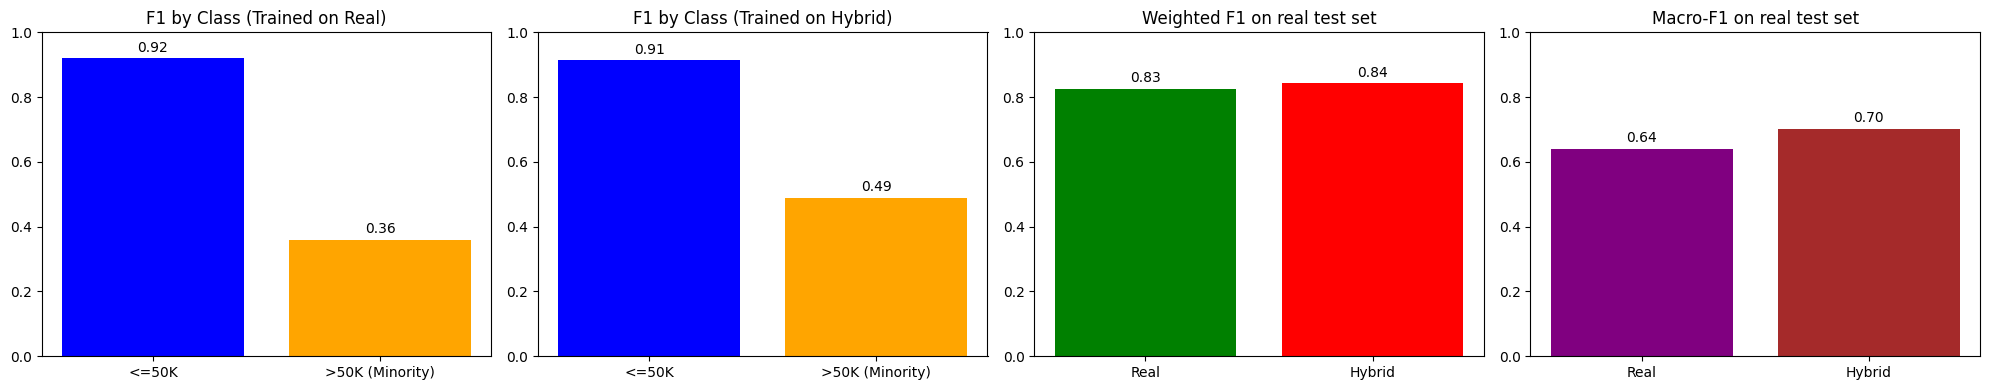

In [17]:
# --- Prepare FFNN config and agents ---
ffnn_config = {
    'input_size': X_train_theta.shape[1],
    'hidden_sizes': [32, 16],
    'output_size': 2,
    'learning_rate': 0.001,
    'batch_size': 32,
    'epochs': 10,
    'type': 'classification',
    'classes': [0, 1],
    'seed': seed
}

agent_theta = FFNNAgent(**ffnn_config)
agent_phi   = FFNNAgent(**ffnn_config)

# --- Build DataLoaders ---
theta_dataset = TensorDataset(
    torch.tensor(X_train_theta, dtype=torch.float32),
    torch.tensor(y_train_theta, dtype=torch.long)
)
phi_dataset = TensorDataset(
    torch.tensor(X_train_phi, dtype=torch.float32),
    torch.tensor(y_train_phi, dtype=torch.long)
)

theta_loader = DataLoader(theta_dataset, batch_size=ffnn_config['batch_size'],
                          shuffle=True,
                          generator=torch.Generator().manual_seed(seed))
phi_loader   = DataLoader(phi_dataset,   batch_size=ffnn_config['batch_size'],
                          shuffle=True,
                          generator=torch.Generator().manual_seed(seed))

# --- Train ---
agent_theta.train(theta_loader)
agent_phi.train(phi_loader)

# --- Predict on θ-test ---
y_pred_theta = np.array(agent_theta.predict(X_test_theta))
y_pred_phi   = np.array(agent_phi.predict(  X_test_theta))

# --- Compute overall weighted F1 once each ---
f1_theta_both = f1_score(y_test_theta, np.round(y_pred_theta), average='weighted')
f1_phi_both   = f1_score(y_test_theta, np.round(y_pred_phi),   average='weighted')

# --- Compute per-class F1s by unpacking average=None ---
f1_theta_0, f1_theta_1 = f1_score(y_test_theta, np.round(y_pred_theta), average=None)
f1_phi_0,   f1_phi_1   = f1_score(y_test_theta, np.round(y_pred_phi),   average=None)

# --- Compute macro-F1 for both models ---
f1_theta_macro = f1_score(y_test_theta, np.round(y_pred_theta), average='macro')
f1_phi_macro   = f1_score(y_test_theta, np.round(y_pred_phi),   average='macro')

# --- Plotting ---
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# 1. Trained on Theta
axes[0].bar(['<=50K', '>50K (Minority)'], [f1_theta_0, f1_theta_1], color=['blue','orange'])
axes[0].set_title('F1 by Class (Trained on Real)')
axes[0].set_ylim(0,1)
for i, v in enumerate([f1_theta_0, f1_theta_1]):
    axes[0].text(i, v+0.02, f"{v:.2f}", ha='center')

# 2. Trained on Phi
axes[1].bar(['<=50K', '>50K (Minority)'], [f1_phi_0, f1_phi_1], color=['blue','orange'])
axes[1].set_title('F1 by Class (Trained on Hybrid)')
axes[1].set_ylim(0,1)
for i, v in enumerate([f1_phi_0, f1_phi_1]):
    axes[1].text(i, v+0.02, f"{v:.2f}", ha='center')

# 3. Weighted F1 comparison (now green and red bars)
axes[2].bar(['Real','Hybrid'], [f1_theta_both, f1_phi_both], color=['green','red'])
axes[2].set_title('Weighted F1 on real test set')
axes[2].set_ylim(0,1)
for i, v in enumerate([f1_theta_both, f1_phi_both]):
    axes[2].text(i, v+0.02, f"{v:.2f}", ha='center')

# 4. Macro-F1 comparison (now purple and brown bars)
axes[3].bar(['Real','Hybrid'], [f1_theta_macro, f1_phi_macro], color=['purple','brown'])
axes[3].set_title('Macro-F1 on real test set')
axes[3].set_ylim(0,1)
for i, v in enumerate([f1_theta_macro, f1_phi_macro]):
    axes[3].text(i, v+0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()